In [ ]:
!pip3 install -r requirements.txt

In [1]:
from huggingface_hub import snapshot_download

In [2]:
dataset_path = snapshot_download(repo_id="biglab/webui-7kbal", repo_type="dataset")
dataset_path

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/home/flynn/.cache/huggingface/hub/datasets--biglab--webui-7kbal/snapshots/2312ad12c6df0715fd808a934cc37ada255517b5'

In [3]:
import enum
import os
import zipfile
import gzip
import json
from glob import glob
import re
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

In [4]:
# Create output dir
d1_path = os.path.join(dataset_path, "dataset1")
if not os.path.exists(d1_path):
    os.mkdir(d1_path)

## Dataset decompression

This code will unpack files only for the first time

In [ ]:
def unpack():
    # Merge 2 zip files
    files = glob(os.path.join(dataset_path, "*.zip*"))
    output = os.path.join(d1_path, "dataset.zip")
    if os.path.exists(output):
        return True # nothing to do
    
    os.system("cat " + ' '.join(sorted(files)) + " > " + output)

    d1_zip = os.path.realpath(output)
    if not zipfile.is_zipfile(d1_zip):
        print("WARNING : bad zip format")
        return False

    with zipfile.ZipFile(output, 'r') as z:
        z.extractall(d1_path)

    return True

In [ ]:
unpack()

## Loading files

In [10]:
dirs = [x for x in os.listdir(d1_path) if os.path.isdir(os.path.join(d1_path, x))]
if len(dirs) == 1:
    dataset_dir = dirs[0]
else:
    dataset_dir = "balanced_7k" #"train_split_web7k"  # SET MANUALLY

In [11]:
#d1_path = r'C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7k\snapshots\666\dataset1'
files = os.path.join(d1_path, dataset_dir)
base_data_path = d1_path
print(files)
print("files number", len(os.listdir(files)))

/home/flynn/.cache/huggingface/hub/datasets--biglab--webui-7kbal/snapshots/2312ad12c6df0715fd808a934cc37ada255517b5/dataset1/balanced_7k
files number 6402


In [12]:
# Load pages metadata

# TODO figure out a proper solution for storing metadata
#meta_path = r"C:\Users\70133\Documents\GitHub\jarvis-core"
# meta_path = "/home/flynn/src/jupyter"
meta_path = "."

with open(os.path.join(meta_path, 'webui/metadata/screenclassification/class_map_enrico.json'), 'r') as f:
    labels = json.load(f)["idx2Label"].values()
#dtypes = {**{'page_id': object, 'file': object}, **dict([(x, np.float64) for x in labels])}
dtypes = {**{'page_id': np.int64, 'file': object}, **dict([(x, np.float64) for x in labels])}

df_c = pd.read_csv(os.path.join(meta_path, 'webui/metadata/screenclassification/silver_webui-multi_topic.csv'), sep=r'[,\\]', names=['page_id', 'file', *labels], dtype=dtypes, engine='python')

In [13]:
df_c.head(5)

,page_id,file,bare,calculator,camera,chat,editor,form,gallery,list,...,mediaplayer,menu,modal,news,other,profile,search,settings,terms,tutorial
0,1655879187811,default_1280-720-screenshot.webp,9.291674e-11,7.130765e-08,7.253227e-06,9.046539e-06,8.187051e-09,7.984676e-08,2.324591e-06,0.983791,...,9.630982e-06,5.211010e-05,1.108446e-03,1.410034e-02,1.907439e-04,2.310613e-08,4.906302e-05,4.191939e-05,6.378857e-04,7.004751e-08
1,1655879187811,default_1536-864-screenshot.webp,1.109577e-12,3.087419e-10,9.532457e-10,1.385165e-11,1.341835e-09,3.822118e-09,1.366081e-09,0.000013,...,6.291726e-08,8.763302e-11,1.148793e-04,3.088464e-07,9.998707e-01,1.503188e-10,1.038731e-09,1.253137e-10,5.714059e-08,9.233252e-07
2,1655879187811,iPad-Pro-screenshot.webp,4.476726e-10,2.628705e-07,4.739139e-05,8.027262e-07,1.768409e-09,3.327144e-06,2.086888e-06,0.946450,...,7.259951e-04,4.811632e-02,1.890350e-04,6.831510e-04,1.278714e-07,2.380704e-06,2.039391e-04,1.932175e-03,1.641989e-03,9.453231e-07
3,1655879187811,iPhone-13 Pro-screenshot.webp,1.740975e-11,2.117407e-08,2.220893e-10,6.500039e-13,3.749291e-13,8.293891e-10,1.001302e-10,0.000012,...,1.541007e-07,2.752847e-09,4.523345e-09,2.618951e-01,2.998420e-11,7.362105e-03,2.464764e-07,2.476263e-10,7.307301e-01,6.493919e-07
4,1655884447196,iPad-Pro-screenshot.webp,1.347118e-05,6.677556e-03,1.288787e-03,2.742077e-05,8.803538e-05,3.809738e-07,4.067358e-02,0.000673,...,1.043205e-06,1.424785e-03,7.473713e-06,2.308492e-01,6.170149e-07,1.024725e-01,6.051495e-01,2.472414e-05,9.113838e-05,8.508272e-03


In [14]:
# Take max of each screenshot and save it
df_c['label_max'] = df_c[labels].idxmax(axis=1)
df_c['certainty'] = df_c[labels].max(axis=1)

df_cf = (df_c.set_index(['page_id', 'file']).sort_index())      # index = (page_id, file)
assert df_cf.index.is_unique   

In [ ]:
df_cf.head(5)

In [ ]:
df_cf["label_max"].value_counts()

## Dataset parsing

In [15]:
class FileType(enum.StrEnum):
    """
    Enum containing all filetypes
    """

    AXTree = "axtree.json.gz",
    BB = "bb.json.gz",
    Box = "box.json.gz",
    Class = "class.json.gz",
    HTML = "html.html",
    Links = "links.json",
    ScreenFull = "screenshot-full.webp",
    Screen = "screenshot.webp",
    Style = "style.json.gz",
    URL = "url.txt",
    Viewport = "viewport.json.gz"

# Helper functions

def ft_is_gz(ft: FileType) -> bool:
    """
    Check if a FileType is a gz file
    """
    return ft in [FileType.AXTree, FileType.BB, FileType.Box, FileType.Class, FileType.Style, FileType.Viewport]

def ft_is_json(ft: FileType) -> bool:
    """
    Check if a FileType is in json format
    """
    return ft in [FileType.AXTree, FileType.BB, FileType.Box, FileType.Class, FileType.Links, FileType.Style, FileType.Viewport]

def ft_is_webp(ft: FileType) -> bool:
    """
    Check if a FileType is a webp image
    """
    return ft in [FileType.ScreenFull, FileType.Screen]

In [16]:
class Page():
    """
    A class which loads page content (screen)
    """
    def __init__(self, path, screen_type: str, debug: bool = True):
        self.screen_type = screen_type
        self.path = path
        self.skip = False

        # Parse screen type
        self.desktop = screen_type.startswith("default")
        if self.desktop:
            (self.width, self.height) = tuple(map(int, screen_type.split('_')[1].split('-')))
        else:
            (self.width, self.height) = (0, 0)

        # Load filenames
        #files = list(filter(lambda x: x.startswith(screen_type), os.listdir(path)))
        self.fnames = dict()
        self.files = dict()
        missing = False

        for ft in FileType:
            file_path = screen_type + "-" + ft.value
            if os.path.exists(os.path.join(self.path, file_path)):
                self.fnames[ft] = file_path
            else:
                missing = True


        if missing:
            # Some files are missing
            if debug:
                for ft, v in self.fnames.items():
                    assert ft_is_webp(ft), "Page::__init__() : non-webp file in partial download : {}".format(v)
            self.skip = True


    def load(self, debug: bool = True, *args):
        if self.skip:
            return
        if len(args) == 0:
            ftypes = FileType
        else:
            ftypes = args

        for ft in ftypes:
            fname = os.path.join(self.path, self.fnames[ft])
            if debug:
                print("Page::load() : loading file {}...".format(self.fnames[ft]))

            if ft_is_webp(ft):
                # Check if the file is empty
                if os.path.getsize(fname) == 0:
                    if debug:
                        print("Page::load() : {} is empty".format(self.fnames[ft]))
                    continue
                self.files[ft] = Image.open(fname)

            elif ft_is_gz(ft):
                # gzip
                with gzip.open(fname) as f:
                    if ft_is_json(ft):
                        self.files[ft] = json.load(f)
                    else:
                        # plaintext
                        self.files[ft] = f.read()
            else:
                # not compressed
                #with open(fname) as f:
                with open(fname, encoding="utf-8", errors="replace") as f:
                    if ft_is_json(ft):
                        self.files[ft] = json.load(f)
                    else:
                        # plaintext
                        self.files[ft] = f.read()
                        

class PageLoader():
    """
    A class which loads multiple pages (with different resolutions). Loads only labels of the specified class
    """
    def __init__(self, path, debug: bool = True, *args):
        self.path = path
        self.page_id = np.int64(os.path.basename(path))

        #print('\nID:', self.page_id)
        self.skip = False

        if debug:
            print("PageLoader()::__init__() : opening", self.page_id)
            #print(os.listdir(self.path))

        # Extract pages
        prefixes = map(lambda x: '-'.join(x.split('-')[:-1]), os.listdir(self.path))
        screen_types = list(filter(lambda x: x.find("screenshot") == -1, list(set(prefixes))))

        # Load pages
        self.pages = dict()
        for s in screen_types:
            page = Page(self.path, s, debug)
            if not page.skip:
                self.pages[s] = page
                self.pages[s].load(debug, *args) # load all

        # Find best page(with bigest width)
        self.best = next(
                (p for p in sorted(self.pages.values(), reverse=True, key=lambda p: p.width)
                 if p.files.get(FileType.ScreenFull)), None)
        
        
        # set screen_type, label and certainty for best Page
        try:
            self.screen_type = self.best.screen_type
        except AttributeError:
            self.screen_type = ''
        try:
            self.label = df_cf.loc[(self.page_id, self.best.screen_type + '-screenshot.webp'), 'label_max']
        except (AttributeError, KeyError):
            self.label = ''
        try:
            self.certainty = df_cf.loc[(self.page_id, self.best.screen_type + '-screenshot.webp'), 'certainty']
        except (AttributeError, KeyError):
            self.certainty = 0.0

    
    def image(self) -> [Image.Image, None]:
        """
        Find and return the largest page image width. Desktop images always have the largest priority
        """
        if self.best and self.best.files.get(FileType.ScreenFull) is not None:
            return self.best.files[FileType.ScreenFull]
        return None

In [17]:
def label_certainty_thresh(c: np.float64) -> bool:      
    return c >= 0.6

In [18]:
def preview(img: Image.Image, width: int) -> Image.Image:
    return img.resize((width, int(img.height / img.width * width)))

1655896648167 1655896696033 1655896788809 1655897028676 1655898116356 
1655898146770 1655898296965 1655898350465 1655898704748 1655898812258 
1655900047326 1655900377936 1655901157715 1655902113723 1655902573853 
1655903421118 1655904325731 1655904376432 1655904394619 1655904445187 
1655905044157 1655905655628 1655905777432 1655906166879 1655906753953 


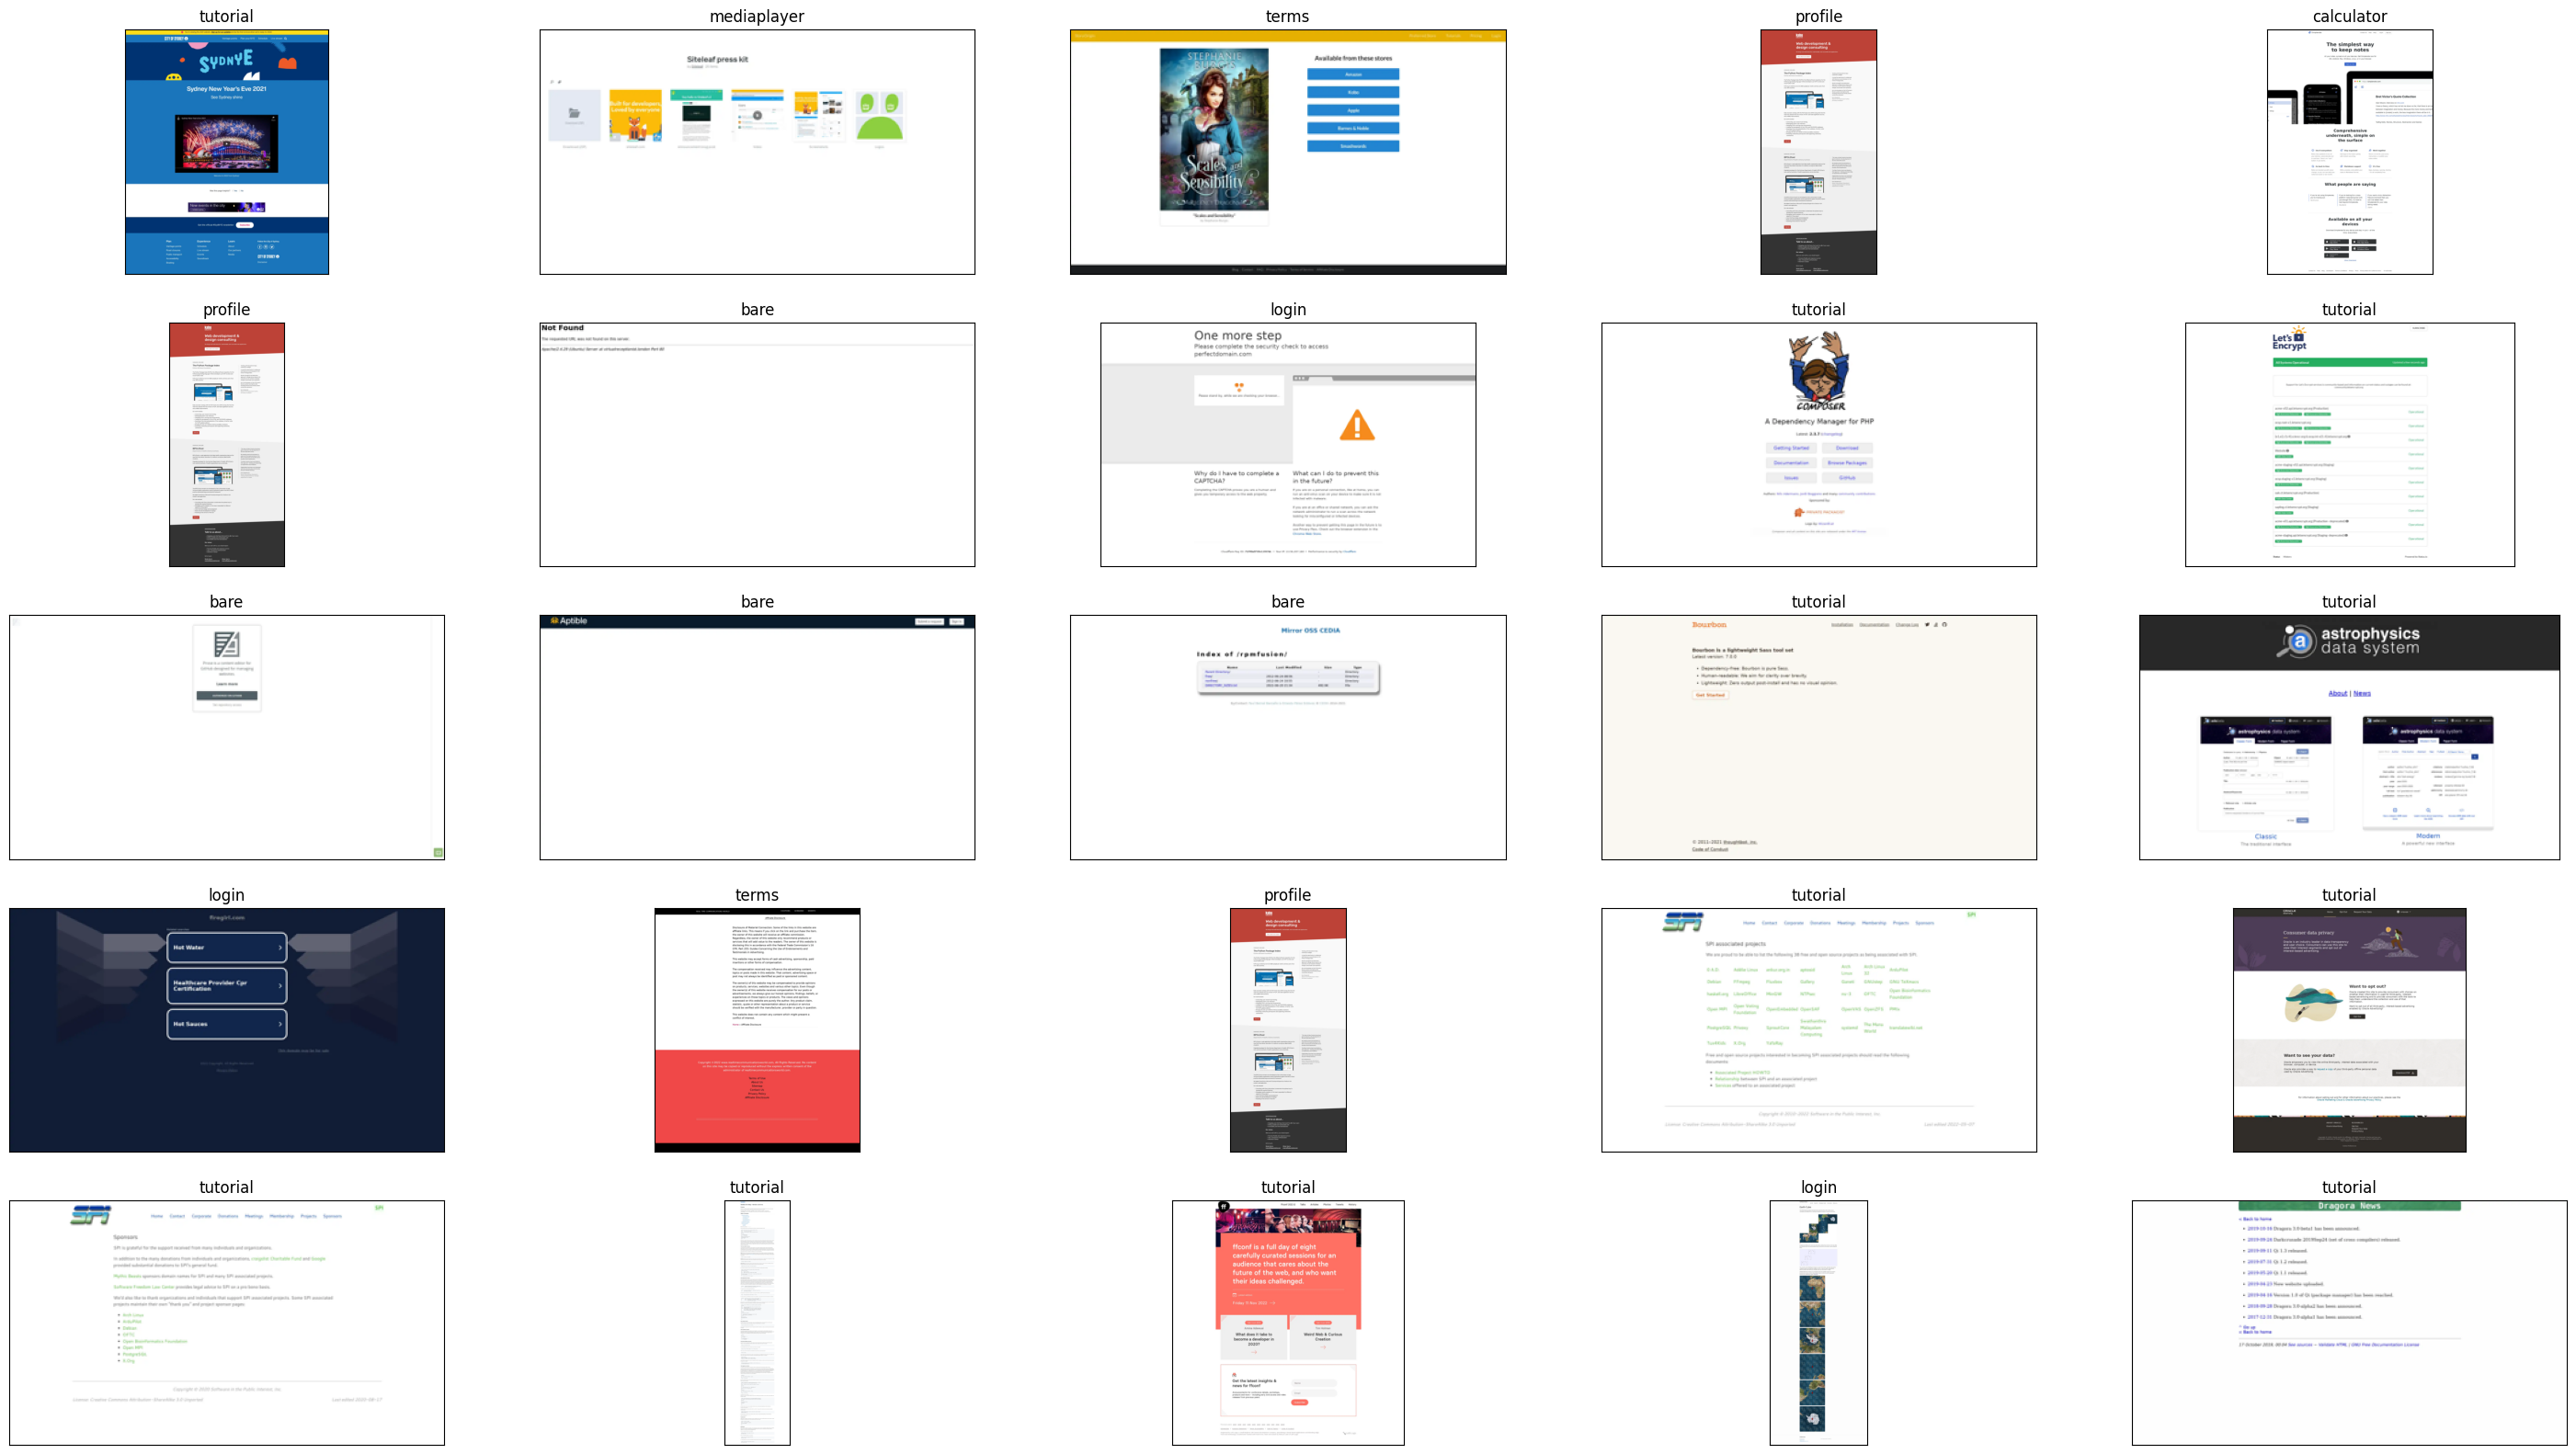

In [19]:
_ = plt.figure(figsize=(36, 20)) # 1920/1080 scaled to 360p
(nrows, ncols) = (5, 5) # Set the grid size
start = nrows*ncols # Start index
skip = 0

files_l = sorted(os.listdir(files))
# for index in range(0, nrows*ncols):
for index in range(0, nrows*ncols):
    while True: # Find matching
        fpath = files_l[index + start + skip]
        # Parse the page
        loader = PageLoader(os.path.join(files, fpath), debug=False)
        if not label_certainty_thresh(loader.certainty):
            skip += 1
            continue # Skip

        # Create a subplot and render an image
        ax = plt.subplot(nrows, ncols, index+1)
        _ = plt.title(loader.label)
        _, _ = plt.xticks([]), plt.yticks([]);
        image = loader.image()
        if image is not None:
            _ = plt.imshow(preview(image, 360))
            print(loader.page_id, end=' ')
            if index % ncols == 4:
                print('')
        else:
            skip += 1
            continue # Load the next sample
        # Else found
        break
_ = plt.show()

## Bounding Boxes

dict_keys(['default_1920-1080', 'iPad-Pro', 'default_1536-864', 'default_1280-720', 'default_1366-768', 'iPhone-13 Pro'])
screen_type: default_1920-1080 page_id: 1655905777432 label: tutorial


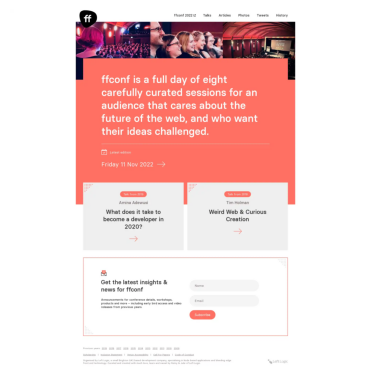

In [22]:
# Take 1655885631145 since it is in huggingface dataset
path = os.path.join(files, '1655905777432')  # 1655888953458
loader = PageLoader(path, debug=False)

# Show
print(loader.pages.keys())
print('screen_type:', loader.screen_type, 'page_id:', loader.page_id, 'label:', loader.label)
plt.imshow(loader.image())
plt.axis("off")
plt.show()

In [23]:
# AXTree
nodes = loader.best.files[FileType.AXTree]['nodes']
print(type(loader.best.files[FileType.AXTree]))
print(json.dumps(nodes, indent=2, ensure_ascii=False))

<class 'dict'>
[
  {
    "nodeId": "1",
    "ignored": false,
    "role": {
      "type": "internalRole",
      "value": "RootWebArea"
    },
    "name": {
      "type": "computedString",
      "value": "ffconf - Web development & JavaScript conference in Brighton, UK",
      "sources": [
        {
          "type": "relatedElement",
          "attribute": "aria-labelledby"
        },
        {
          "type": "attribute",
          "attribute": "aria-label"
        },
        {
          "type": "attribute",
          "attribute": "aria-label",
          "superseded": true
        },
        {
          "type": "relatedElement",
          "value": {
            "type": "computedString",
            "value": "ffconf - Web development & JavaScript conference in Brighton, UK"
          },
          "nativeSource": "title"
        },
        {
          "type": "attribute",
          "attribute": "title",
          "superseded": true
        }
      ]
    },
    "properties": [
      {


In [24]:
# BB
bb = loader.best.files.get(FileType.BB)

# turn bb keys to int
bb = { int(b_id): b for b_id, b in bb.items() }

print(type(bb))
for b_id, b in bb.items():
    print(b_id, b)

<class 'dict'>
3 {'x': 0, 'y': 0, 'width': 1920, 'height': 1080}
6 {'x': 360, 'y': 70, 'width': 1200, 'height': 1290.65625}
10 {'x': 500, 'y': 349.984375, 'width': 920, 'height': 388.546875}
16 {'x': 360, 'y': 0, 'width': 1200, 'height': 1965.65625}
17 {'x': 360, 'y': 0, 'width': 1200, 'height': 70}
18 {'x': 877, 'y': 13, 'width': 643, 'height': 43}
19 {'x': 877, 'y': 13, 'width': 643, 'height': 43}
20 {'x': 897, 'y': 13, 'width': 119, 'height': 43}
21 {'x': 1004, 'y': 29, 'width': 12, 'height': 12}
22 {'x': 1056, 'y': 13, 'width': 45, 'height': 43}
23 {'x': 1141, 'y': 13, 'width': 67, 'height': 43}
24 {'x': 1248, 'y': 13, 'width': 62, 'height': 43}
25 {'x': 1350, 'y': 13, 'width': 65, 'height': 43}
26 {'x': 1455, 'y': 13, 'width': 65, 'height': 43}
28 {'x': 400, 'y': 269.984375, 'width': 1120, 'height': 1050.671875}
29 {'x': 500, 'y': 766.53125, 'width': 920, 'height': 103}
30 {'x': 390, 'y': 949.53125, 'width': 1140, 'height': 371.125}
33 {'x': 595.5, 'y': 1046.53125, 'width': 159, '

In [25]:
# map backendDOMNodeId -> AXTree node
backend_id_to_axnode = {
    node.get("backendDOMNodeId"): node
    for node in nodes
    if "backendDOMNodeId" in node
}

bb_info = {}
for b_id, b in bb.items():
    ax_node = backend_id_to_axnode.get(b_id)
    if not ax_node:
        continue

    bb_info[b_id] = {
        "name": ax_node.get("name", {}).get("value", ""),
        "name_t": ax_node.get("name", {}).get("type", ""),
        "role": ax_node.get("role", {}).get("value", ""),
        "role_t": ax_node.get("role", {}).get("type", ""),
        "ignored": ax_node.get("ignored", False),
        "box": b
    }

# print(type(backend_id_to_axnode), json.dumps(backend_id_to_axnode, indent=2, ensure_ascii=False))
# print(type(bb_info),'\n', json.dumps(bb_info, indent=2, ensure_ascii=False))

In [26]:
ignored_ids = [] 
for x_id, x in bb_info.items():
    if x["ignored"] == True:
        print(x_id, x['ignored'], x['role_t'], x['role'], '"', x['name'], '"', x['box'])
        ignored_ids.append(x_id)

print(set(ignored_ids))

21 True role none "  " {'x': 1004, 'y': 29, 'width': 12, 'height': 12}
29 True role none "  " {'x': 500, 'y': 766.53125, 'width': 920, 'height': 103}
30 True role none "  " {'x': 390, 'y': 949.53125, 'width': 1140, 'height': 371.125}
39 True role none "  " {'x': 0, 'y': 0, 'width': 1920, 'height': 2025.65625}
40 True role none "  " {'x': 360, 'y': 0, 'width': 1200, 'height': 1965.65625}
44 True role none "  " None
45 True role none "  " None
46 True role none "  " None
47 True role none "  " None
48 True role none "  " {'x': 410, 'y': 1370.65625, 'width': 1100, 'height': 409}
53 True role none "  " {'x': 400, 'y': 1915.65625, 'width': 1120, 'height': 50}
62 True role none "  " {'x': 982, 'y': 1482.65625, 'width': 380, 'height': 217}
66 True role none "  " None
88 True role none "  " {'x': 408, 'y': 957.53125, 'width': 534, 'height': 355.125}
92 True role none "  " {'x': 978, 'y': 957.53125, 'width': 534, 'height': 314.5}
100 True role none "  " {'x': 1010, 'y': 1502.65625, 'width': 50,

In [27]:
unic = {info["name_t"] for info in bb_info.values()}
print(unic)

{'', 'computedString'}


In [28]:
# roles filter
allowed_roles = {info["role"] for info in bb_info.values()}
print(allowed_roles)
# allowed_roles.discard('StaticText')
# allowed_roles.discard('heading')
# allowed_roles.discard('paragraph')
# allowed_roles.discard('RootWebArea')
# allowed_roles.discard('navigation')

{'contentinfo', 'LabelText', 'PluginObject', 'paragraph', 'textbox', 'link', 'list', 'Section', 'RootWebArea', 'none', 'StaticText', 'HeaderAsNonLandmark', 'banner', 'button', 'listitem', 'navigation', 'main', 'Abbr', 'heading', 'generic'}


In [29]:
def rectangle_intersaction_area_pr(p, c):
    if(p["width"] == 0 or p["height"] == 0):
        return 0
    # Координаты пересечения
    x_left   = max(p["x"], c["x"])
    y_bottom = max(p["y"], c["y"])
    x_right  = min(p["x"] + p["width"], c["x"] + c["width"])
    y_top    = min(p["y"] + p["height"], c["y"] + c["height"])
    
    # Проверка: есть ли вообще пересечение
    if x_right > x_left and y_top > y_bottom:
        parent_area = (p["x"] + p["width"]) * (p["y"] + p["height"])
        return (x_right - x_left) * (y_top - y_bottom) / parent_area
    else:
        return 0  # Нет пересечения

In [30]:
nodes_by_id = {node["nodeId"]: node for node in nodes}


statictext_child_counts = []

for node_id, node in nodes_by_id.items():
    role_info = node.get("role")
    if role_info and role_info.get("value") == "StaticText":
        child_ids = node.get("childIds", [])
        count = len(child_ids)
        statictext_child_counts.append((node_id, count))

# Вывод
print("Узлы с role_value = 'StaticText' и количеством дочерних элементов:")
for node_id, count in statictext_child_counts:
    print(f"Node {node_id}: {count} child(ren)")


Узлы с role_value = 'StaticText' и количеством дочерних элементов:
Node 31: 0 child(ren)
Node 50: 0 child(ren)
Node 18: 0 child(ren)
Node 110: 0 child(ren)
Node 116: 0 child(ren)
Node 63: 0 child(ren)
Node 64: 0 child(ren)
Node 123: 0 child(ren)
Node 125: 0 child(ren)
Node 75: 0 child(ren)
Node 76: 0 child(ren)
Node 77: 0 child(ren)
Node 78: 0 child(ren)
Node 79: 0 child(ren)
Node 80: 0 child(ren)
Node 81: 0 child(ren)
Node 82: 0 child(ren)
Node 83: 0 child(ren)
Node 84: 0 child(ren)
Node 85: 0 child(ren)
Node 86: 0 child(ren)
Node 128: 0 child(ren)
Node 130: 0 child(ren)
Node 132: 0 child(ren)
Node 134: 0 child(ren)
Node 102: 0 child(ren)
Node 105: 0 child(ren)
Node 113: 0 child(ren)
Node 114: 0 child(ren)
Node 119: 0 child(ren)
Node 120: 0 child(ren)
Node 121: 0 child(ren)
Node 127: 0 child(ren)
Node 129: 0 child(ren)
Node 131: 0 child(ren)
Node 133: 0 child(ren)
Node 135: 0 child(ren)
Node 136: 0 child(ren)
Node 138: 0 child(ren)
Node 139: 0 child(ren)
Node 140: 0 child(ren)
Node 14

In [31]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))

<class 'dict'> {
  "1": {
    "nodeId": "1",
    "ignored": false,
    "role": {
      "type": "internalRole",
      "value": "RootWebArea"
    },
    "name": {
      "type": "computedString",
      "value": "ffconf - Web development & JavaScript conference in Brighton, UK",
      "sources": [
        {
          "type": "relatedElement",
          "attribute": "aria-labelledby"
        },
        {
          "type": "attribute",
          "attribute": "aria-label"
        },
        {
          "type": "attribute",
          "attribute": "aria-label",
          "superseded": true
        },
        {
          "type": "relatedElement",
          "value": {
            "type": "computedString",
            "value": "ffconf - Web development & JavaScript conference in Brighton, UK"
          },
          "nativeSource": "title"
        },
        {
          "type": "attribute",
          "attribute": "title",
          "superseded": true
        }
      ]
    },
    "properties": [
   

In [ ]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
# print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))

root_node = next(
    node for node in nodes
    if "parentId" not in node or node["parentId"] is None
)
# print(root_node.get("childIds", []))

# def build_tree(node):
#     children = []
#     for child_id in node.get("childIds", []):
#         child_node = nodes_by_id.get(child_id)
#         if child_node:
#             children.append(build_tree(child_node))
#     return {
#         "id": node["nodeId"],
#         "back_id": node.get("backendDOMNodeId"),
#         "ignored": node.get("ignored"),
#         "name": node.get("name", {}).get("value", ""),
#         "role": node.get("role", {}).get("value", ""),
#         "children": children
#     }

def build_tree(node):
    children = []
    for child_id in node.get("childIds", []):
        child_node = nodes_by_id.get(child_id)
        if child_node:
            child_back_id = child_node.get("backendDOMNodeId")
            child_box = bb.get(child_back_id) if child_back_id is not None else None
            parent_back_id = node.get("backendDOMNodeId")
            parent_box = bb.get(parent_back_id) if parent_back_id is not None else None

            # По умолчанию площадь пересечения — 0
            intersection_area = 0
            if parent_box and child_box:
                intersection_area = rectangle_intersaction_area_pr(parent_box, child_box)

            child_tree = build_tree(child_node)
            child_tree["intersection_area"] = intersection_area
            children.append(child_tree)

    return {
        "id": node["nodeId"],
        "back_id": node.get("backendDOMNodeId"),
        "ignored": node.get("ignored"),
        "name": node.get("name", {}).get("value", ""),
        "role": node.get("role", {}).get("value", ""),
        "children": children
    }

# вызов
tree = build_tree(root_node)
tree["intersection_area"] = 0


def print_tree(node, indent=0):
    if not isinstance(node, dict):
        print("Unexpected node:", node)
        return

    prefix = " " * (indent * 2)
    role = node.get("role", "")
    name = node.get("name", "")
    n_id = node.get("id", "")
    b_id = node.get("back_id", "")
    ignored = node.get("ignored", "")
    in_area = node.get("intersection_area", "")
    if float(in_area) > 0.5:
        print(f"{prefix}- {b_id} ({in_area}) ({indent}) ({role}) ({ignored}) ")

    for child in node.get("children", []):
        print_tree(child, indent + 1)

print_tree(tree)

In [32]:
def build_tree(node):
    children = []
    for child_id in node.get("childIds", []):
        child_node = nodes_by_id.get(child_id)
        if child_node:
            children.append(build_tree(child_node))

    return {
        "id": node["nodeId"],
        "back_id": node.get("backendDOMNodeId"),
        "ignored": node.get("ignored"),
        "name": node.get("name", {}).get("value", ""),
        "role": node.get("role", {}).get("value", ""),
        "modified": False,
        "children": children
    }


def print_tree(node, indent=0):
    if not isinstance(node, dict):
        print("Unexpected node:", node)
        return

    prefix = " " * (indent * 2)
    role = node.get("role", "")
    name = node.get("name", "")
    n_id = node.get("id", "")
    b_id = node.get("back_id", "")
    ignored = node.get("ignored", "")
    modified = node.get("modified", "")
    print(f"{prefix}- {b_id} ({ignored}) ({indent}) ({role})")

    for child in node.get("children", []):
        print_tree(child, indent + 1)

def is_useless_branch(node):
    """Возвращает True, если это ветка из ignored-узлов с role=none"""
    if not node.get("ignored", False):
        return False
    if node.get("role") != "none":
        return False
    if not node.get("children"):
        return True
    return all(is_useless_branch(child) for child in node["children"])

In [33]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
# print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))
root_node = next(
    node for node in nodes
    if "parentId" not in node or node["parentId"] is None
)
# print(root_node.get("childIds", []))

def transform_tree(node):
    global mod_count, mod_name_count 
    global valid_b_ids
    # if node["ignored"] == False:
    valid_b_ids.append(node["back_id"])

    cleaned_children = []
    for child in node.get("children", []):
        if not is_useless_branch(child):
            cleaned_children.append(child)

    node["children"] = cleaned_children
    
    new_children = []
    skip = False

    # If only one child
    if len(node["children"]) == 1:
        child = node["children"][0]
        if (child["role"] in ["StaticText", "link", "heading", "paragraph", "gridcell"] and child["name"]):
           # or (child["ignored"] == True and len(child["children"]) == 0):
            print(f"before role: {node['role']}\tafter role: {child['role']}\t before name: {node['name']} after name: {child['name']}")
            if node["name"]:
                mod_name_count += 1
            node["name"] = child["name"]
            node["modified"] = True
            mod_count += 1
            skip = True  # skip child

    # Traverse the other children
    if not skip:
        for child in node["children"]:
            if is_useless_branch(child):
                continue
            transformed_child = transform_tree(child)
            new_children.append(transformed_child)

    node["children"] = new_children
    return node


valid_b_ids = []
mod_count = 0
mod_name_count = 0

tree = build_tree(root_node)
tree = transform_tree(tree)

print(f"\nModified nodes: {mod_count} \t chaged names: {mod_name_count}")
print(len(valid_b_ids), 'vs' , len(nodes_by_id), '\n', valid_b_ids, '\n')
print_tree(tree)

before role: heading	after role: link	 before name: ffconf after name: ffconf
before role: listitem	after role: link	 before name:  after name: ffconf 2022
before role: listitem	after role: link	 before name:  after name: Talks
before role: listitem	after role: link	 before name:  after name: Articles
before role: listitem	after role: link	 before name:  after name: Photos
before role: listitem	after role: link	 before name:  after name: Tweets
before role: listitem	after role: link	 before name:  after name: History
before role: heading	after role: StaticText	 before name: ffconf is a full day of eight carefully curated sessions for an audience that cares about the future of the web, and who want their ideas challenged. after name: ffconf is a full day of eight carefully curated sessions for an audience that cares about the future of the web, and who want their ideas challenged.
before role: paragraph	after role: StaticText	 before name:  after name: Latest edition
before role: headin

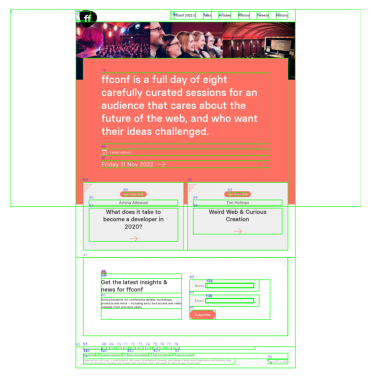

Image saved in: /home/flynn/.cache/huggingface/hub/datasets--biglab--webui-7kbal/snapshots/2312ad12c6df0715fd808a934cc37ada255517b5/dataset1/bb/boxed.png


In [34]:
pil_img = loader.image()                                    # WebPImageFile
img_rgb = np.array(pil_img)                                 # RGB
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)          # BGR for OpenCV

# Draw boxes
for b_id, b in bb.items():
    if b is None or b["width"] == 0 or b["height"] == 0:
        continue
    # if not bb_info[b_id]["role_t"] == 'role': continue
    if b_id in ignored_ids:
        continue
    if not b_id in valid_b_ids:
        continue
    color_b = (0, 255, 0)
    color_t = (255, 0, 0)
    # if b_id in {3, 117, 119, 38, 39, 51, 118, 40, 128, 129}: 
    #     color_b = (0, 0, 255)
    #     color_t = (0, 0, 0)

    
    x1, y1 = int(b["x"]), int(b["y"])
    x2 = int(b["x"] + b["width"])
    y2 = int(b["y"] + b["height"])
    
    name = bb_info[b_id]["name"]
    role = bb_info[b_id]["role"]
    text_coordinates = (x1, max(y1 - 8, 0))
    if y1 < 20:
        text_coordinates = (x1, max(y1 + 20, 0))
    # if not bb_info[b_id]["ignored"] and role in allowed_roles:
    
    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color_b, 2) # Green, width = 2px
    cv2.putText(img_bgr, str(b_id), text_coordinates, cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_t, 1) # Text

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Back to RGB

# Show
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# Save
out_dir = os.path.join(base_data_path, 'bb')
os.makedirs(out_dir, exist_ok=True)
#out_dir.mkdir(parents=True, exist_ok=True)
out_path = os.path.join(out_dir, "boxed.png")

if not cv2.imwrite(str(out_path), img_bgr):
    raise RuntimeError("error")
print("Image saved in:", out_path)

## Other Bounding Boxes

In [ ]:
def get_bb_and_info(filename):
    path = os.path.join(base_data_path, 'train_split_web7k', filename)
    loader = PageLoader(path, debug=False)
    
    # AXTree
    nodes = loader.best.files[FileType.AXTree]['nodes']
    
    # BB
    bb = loader.best.files.get(FileType.BB)
    bb = { int(b_id): b for b_id, b in bb.items() } # turn bb keys to int
    
    # map backendDOMNodeId -> AXTree node
    backend_id_to_axnode = {
        node.get("backendDOMNodeId"): node
        for node in nodes
        if "backendDOMNodeId" in node
    }
    
    bb_info = {}
    for b_id, b in bb.items():
        ax_node = backend_id_to_axnode.get(b_id)
        if not ax_node:
            continue
    
        bb_info[b_id] = {
            "name": ax_node.get("name", {}).get("value", ""),
            # "name_t": ax_node.get("name", {}).get("type", ""),
            "role": ax_node.get("role", {}).get("value", ""),
            # "role_t": ax_node.get("role", {}).get("type", ""),
            "ignored": ax_node.get("ignored", False),
            # "box": b
        }

    # Show
    print(loader.pages.keys())
    print('screen_type:', loader.screen_type, 'page_id:', loader.page_id, 'label:', loader.label)
    plt.imshow(loader.image())
    plt.axis("off")
    plt.show()
    # print(type(loader.best.files[FileType.AXTree]))
    # print(json.dumps(nodes, indent=2, ensure_ascii=False))
    # print(type(bb))
    # for b_id, b in bb.items():
    #     print(b_id, b)
    # print(type(backend_id_to_axnode), json.dumps(backend_id_to_axnode, indent=2, ensure_ascii=False))
    # print(type(bb_info),'\n', json.dumps(bb_info, indent=2, ensure_ascii=False))

    return bb, bb_info, loader.image()

In [ ]:
def boxed_image(pil_img, bb, bb_info, out_dir, p_name = ''):
    img_rgb = np.array(pil_img)                                 # RGB
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)          # BGR for OpenCV
    
    # Draw boxes
    for b_id, b in bb.items():
        if b is None or b["width"] == 0 or b["height"] == 0:
            continue
            
        color_b = (0, 255, 0)
        color_t = (255, 0, 0)
        
        x1, y1 = int(b["x"]), int(b["y"])
        x2 = int(b["x"] + b["width"])
        y2 = int(b["y"] + b["height"])
        
        name = bb_info[b_id]["name"]
        role = bb_info[b_id]["role"]
        
        text_coordinates = (x1, max(y1 - 8, 0))
        if y1 < 20:
            text_coordinates = (x1, max(y1 + 20, 0))
            
        if str(role) == p_name:
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color_b, 2) # Green, width = 2px
            cv2.putText(img_bgr, str(b_id), text_coordinates, cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_t, 1) # Text
    
    cv2.putText(img_bgr, p_name, (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2) # Text

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Back to RGB
    
    # Show
    # plt.imshow(img_rgb)
    # plt.axis("off")
    # plt.show()

    # Save
    os.makedirs(out_dir, exist_ok=True)
    # out_dir.mkdir(parents=True, exist_ok=True)
    out_path = os.path.join(out_dir, f"boxed_{p_name}.png")
    
    if not cv2.imwrite(str(out_path), img_bgr):
        raise RuntimeError("error")
    print(f"Role:{p_name}. Image saved in:", out_path)

In [ ]:
sites_to_go = {'1655885631145', '1655888953458', '1655890112189'}

for site in sites_to_go:
    bb1, bb_info1, img = get_bb_and_info(site)
    
    allowed_roles1 = {info["role"] for info in bb_info1.values()}
    print(allowed_roles1)
    
    out_dir1 = os.path.join(base_data_path, 'bb', site)
    
    for role in allowed_roles1:
        boxed_image(img, bb1, bb_info1, out_dir1, role)

In [ ]:
roles_unic = {'complementary', 'figure', 'button', 'tab', 'none', 'LayoutTableCell', 'tablist', 'article', 'IframePresentational',
              'Legend', 'navigation', 'gridcell', 'Section', 'spinbutton', 'DisclosureTriangle', 'img', 'DescriptionList', 'searchbox',
              'RootWebArea', 'group', 'Figcaption', 'row', 'Iframe', 'combobox', 'Pre', 'heading', 'menubar', 'DescriptionListDetail', 'menu',
              'separator', 'region', 'LineBreak', 'HeaderAsNonLandmark', 'columnheader', 'emphasis', 'listbox', 'rowheader', 'form', 'option',
              'textbox', 'link', 'LabelText', 'MenuListPopup', 'contentinfo', 'alertdialog', 'FooterAsNonLandmark', 'dialog', 'paragraph',
              'status', 'ListMarker', 'main', 'switch', 'Video', 'Abbr', 'tabpanel', 'grid', 'time', 'table', 'StaticText', 'listitem',
              'DescriptionListTerm', 'insertion', 'PluginObject', 'checkbox', 'menuitem', 'superscript', 'generic', 'banner', 'list',
              'LayoutTableRow', 'strong', 'LayoutTable', 'search', 'blockquote', 'Details'}
print(sorted(roles_unic))

## Image viewer

In [ ]:
bb_path = os.path.join(d1_path, "bb")

In [ ]:
pages = os.listdir(bb_path)
pages

In [ ]:
cur_page = 0
fpath = os.path.join(bb_path, pages[cur_page])
print(os.listdir(fpath))

for fname in os.listdir(fpath):
    print(fname)
    #with open(os.path.join(fpath, fname), 'rb') as f:
    img = Image.open(os.path.join(fpath, fname))
    _ = plt.imshow(img)
    _ = plt.axis("off")
    plt.show()

# Conversion

In [42]:
from widget_spec import (
    Widget,
    WidgetType,
    WidgetHint,
    LINK_ROLES,
    MAIN_ROLES,
    role_to_leaf_type,
    role_is_container,
)


def _layout_hint(child_bboxes):
    """
    Given the list of child bboxes that actually participated in a block
    (None entries for children without geometry), return VBOX / HBOX / None.

    Rule: look at pairs of adjacent, geometry-bearing children. For each pair
    classify it as vertical (y-ranges disjoint) or horizontal (x-ranges
    disjoint). Majority wins; ties / insufficient signal -> no hint.
    """
    boxes = [b for b in child_bboxes if b and b.get("width", 0) > 0 and b.get("height", 0) > 0]
    if len(boxes) < 2:
        return None
    v = h = 0
    for a, b in zip(boxes, boxes[1:]):
        ax1, ay1 = a["x"], a["y"]
        ax2, ay2 = ax1 + a["width"], ay1 + a["height"]
        bx1, by1 = b["x"], b["y"]
        bx2, by2 = bx1 + b["width"], by1 + b["height"]
        y_gap = by1 >= ay2 or ay1 >= by2
        x_gap = bx1 >= ax2 or ax1 >= bx2
        if y_gap and not x_gap:
            v += 1
        elif x_gap and not y_gap:
            h += 1
        elif y_gap and x_gap:
            # diagonal — pick the larger separation
            if (by1 - ay2) > (bx1 - ax2):
                v += 1
            else:
                h += 1
    if v > h:
        return WidgetHint.VBOX
    if h > v:
        return WidgetHint.HBOX
    return None


def ax_to_widget(node, bb=None) -> [Widget, None]:
    """
    Recursively convert a cleaned AXTree node (as produced by `build_tree` /
    `transform_tree`) into the internal Widget representation.

    Rules are applied bottom-up:
      * leaf roles (StaticText, link, img, ...)   -> leaf widget with `name`
      * container roles wrapping widget children  -> `block` widget
      * single-child transparent wrappers collapse upward
      * `main` / `RootWebArea` adds the `main` hint to the produced widget
      * a `block` with geometry gets a `vbox` or `hbox` hint when its children
        clearly stack along one axis (using `bb` for bounding boxes)

    `bb` is `{backendDOMNodeId: {x, y, width, height}}`; it is consumed here
    and never stored on the Widget.

    Returns None for branches that reduce to nothing (empty containers, empty
    text leaves).
    """
    role = node.get("role", "") or ""
    name = (node.get("name", "") or "").strip()

    child_pairs = []  # (widget, child_bbox) aligned with produced widgets
    for child in node.get("children", []):
        w = ax_to_widget(child, bb)
        if w is not None:
            cb = bb.get(child.get("back_id")) if bb else None
            child_pairs.append((w, cb))
    child_widgets = [w for w, _ in child_pairs]

    leaf_type = role_to_leaf_type(role)

    # Link carrying children stays a link but wraps them.
    if role in LINK_ROLES:
        if not child_widgets and not name:
            return None
        return Widget(
            type=WidgetType.LINK,
            name=name,
            children=child_widgets,
            node_id=node.get("id"),
            back_id=node.get("back_id"),
            role=role,
        )

    # Leaf reductions (text / image, and other non-link leaf roles).
    if leaf_type is not None and not child_widgets:
        if leaf_type == WidgetType.TEXT and not name:
            return None
        return Widget(
            type=leaf_type,
            name=name,
            node_id=node.get("id"),
            back_id=node.get("back_id"),
            role=role,
        )

    # No widget children: nothing to wrap.
    if not child_widgets:
        return None

    # Transparent single-child container: bubble the child up, applying hints.
    if len(child_widgets) == 1 and role_is_container(role):
        w = child_widgets[0]
        if role in MAIN_ROLES:
            w.add_hint(WidgetHint.MAIN)
        return w

    w = Widget(
        type=WidgetType.BLOCK,
        name=name,
        children=child_widgets,
        node_id=node.get("id"),
        back_id=node.get("back_id"),
        role=role,
    )
    if role in MAIN_ROLES:
        w.add_hint(WidgetHint.MAIN)
    layout = _layout_hint([cb for _, cb in child_pairs])
    if layout is not None:
        w.add_hint(layout)
    return w

In [43]:
widget_root = ax_to_widget(tree, bb)
if widget_root is not None:
    print(widget_root.pretty())
else:
    print("AXTree reduced to empty widget tree")

[block](main,vbox) role='none' name=''
  [text](-) role='heading' name='ffconf'
  [block](main,vbox) role='Section' name=''
    [block](vbox) role='HeaderAsNonLandmark' name=''
      [text](-) role='heading' name='ffconf is a full day of eight carefully curated sessions for an audience that cares about the future of the web, and who want their ideas challenged.'
      [block](vbox) role='none' name=''
        [text](-) role='paragraph' name='Latest edition'
        [text](-) role='heading' name='Friday 11 Nov 2022'
    [block](hbox) role='none' name=''
      [block](vbox) role='none' name=''
        [text](-) role='StaticText' name='Talk from 2019'
        [text](-) role='paragraph' name='Amina Adewusi'
        [link](-) role='link' name='What does it take to become a developer in 2020?'
      [block](vbox) role='none' name=''
        [text](-) role='StaticText' name='Talk from 2018'
        [text](-) role='paragraph' name='Tim Holman'
        [link](-) role='link' name='Weird Web & Cu

In [44]:
from widget_html import save_document

if widget_root is not None:
    os.makedirs("renderer_output", exist_ok=True)
    out_html = os.path.join("renderer_output", f'widget_{loader.page_id}.html')
    #os.makedirs(os.path.dirname(out_html), exist_ok=True)
    save_document(widget_root, out_html, title=f"page {loader.page_id}")
    print("Widget HTML saved in:", out_html)

Widget HTML saved in: renderer_output/widget_1655905777432.html
